# ML Recruitment Task: Heart Disease Dataset Analysis
**Dataset:** UCI Heart Disease Dataset (Cleveland subset, 303 patients, 14 clinical attributes)

**Regression target:** `chol` (serum cholesterol, mg/dl)

This notebook works through four phases — exploration, cleaning, feature engineering, and linear regression — with an emphasis on justifying every decision and reporting results honestly, rather than chasing a high R².

## Introduction
The Cleveland Heart Disease dataset is best known as a *classification* dataset (predicting presence of heart disease). Here we repurpose it for a harder, less common task: using a patient's other clinical measurements to predict their **serum cholesterol**. Cholesterol is influenced by diet, genetics, and medication use — none of which are recorded here — so this is a good test of whether we can reason honestly about a model's limitations rather than overclaiming performance.

## Phase 1: Understanding the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('heart.csv')
print("Dataset shape:", df.shape)


Dataset shape: (303, 14)


### 1.1 Initial inspection

In [2]:
print("Column names and dtypes:\n")
print(df.dtypes)


Column names and dtypes:

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca              str
thal            str
target        int64
dtype: object


In [3]:
print("First 5 rows:")
df.head()


First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [4]:
print("Last 5 rows:")
df.tail()


Last 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 33.3 KB


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,303.0,NaN,NaN,NaN,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,NaN,NaN,NaN,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,NaN,NaN,NaN,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,NaN,NaN,NaN,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,NaN,NaN,NaN,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,NaN,NaN,NaN,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,NaN,NaN,NaN,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,NaN,NaN,NaN,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,NaN,NaN,NaN,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,NaN,NaN,NaN,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


**Note:** the `target` column here is the original 0–4 heart-disease diagnosis label from the UCI repository. It is *not* used anywhere in this task — our regression target is `chol` — but we keep it in the dataframe for context since some EDA below touches on it as a categorical grouping variable.

### 1.2 Missing values investigation
The raw UCI file encodes missing values as the string `'?'` rather than a proper `NaN`, which is why `df.describe()` above did not flag any missing values even though we will find some.

In [7]:
# Detect '?' characters column by column
print("Occurrences of '?' per column:\n")
for col in df.columns:
    n_q = (df[col].astype(str) == '?').sum()
    if n_q > 0:
        print(f"  {col}: {n_q}")


Occurrences of '?' per column:

  ca: 4
  thal: 2


In [8]:
# Confirm these are specifically in ca and thal
print("Rows where ca == '?':")
print(df[df['ca'] == '?'][['ca', 'thal']])
print("\nRows where thal == '?':")
print(df[df['thal'] == '?'][['ca', 'thal']])


Rows where ca == '?':
    ca thal
166  ?    3
192  ?    7
287  ?    7
302  ?    3

Rows where thal == '?':
    ca thal
87   0    ?
266  0    ?


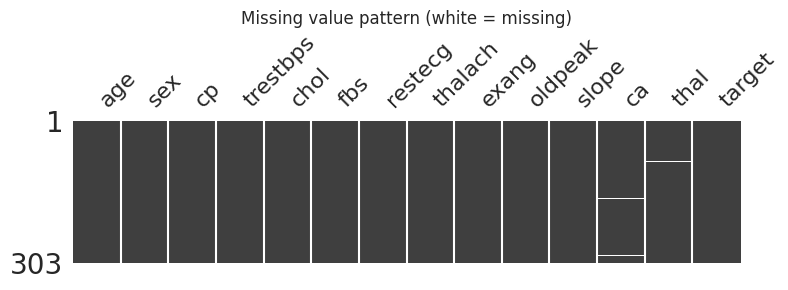

In [9]:
# Visualize missingness (after converting '?' to NaN for plotting purposes only)
df_missing_view = df.replace('?', np.nan)
df_missing_view[['ca', 'thal']] = df_missing_view[['ca', 'thal']].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
msno.matrix(df_missing_view, ax=ax, sparkline=False)
plt.title("Missing value pattern (white = missing)")
plt.tight_layout()
plt.show()


**Interpretation:** missingness is confined to two columns, `ca` (4 rows) and `thal` (2 rows), and the pattern is sparse and does not overlap between the two — no single row is missing both. With only 6 affected rows out of 303 (< 2% of the data), this is a minor data-quality issue rather than a structural one.

### 1.3 Statistical analysis of numerical columns and clinical plausibility checks

In [10]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_num = df.copy()
df_num[numeric_cols] = df_num[numeric_cols].apply(pd.to_numeric, errors='coerce')

df_num[numeric_cols].describe()


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [11]:
# Clinical plausibility checks
checks = {
    'age out of [0, 120]': ~df_num['age'].between(0, 120),
    'trestbps == 0 (impossible resting BP)': df_num['trestbps'] == 0,
    'trestbps > 200 (extreme hypertension)': df_num['trestbps'] > 200,
    'chol == 0 (impossible)': df_num['chol'] == 0,
    'chol > 400 (extreme, verify not error)': df_num['chol'] > 400,
    'thalach == 0 (impossible)': df_num['thalach'] == 0,
    'thalach > 220 (exceeds theoretical max HR)': df_num['thalach'] > 220,
    'oldpeak < 0 (impossible ST depression)': df_num['oldpeak'] < 0,
}
for name, mask in checks.items():
    print(f"{name}: {mask.sum()} rows")
    if mask.sum() > 0:
        print(df_num.loc[mask, ['age','trestbps','chol','thalach','oldpeak']])


age out of [0, 120]: 0 rows
trestbps == 0 (impossible resting BP): 0 rows
trestbps > 200 (extreme hypertension): 0 rows
chol == 0 (impossible): 0 rows
chol > 400 (extreme, verify not error): 4 rows
     age  trestbps  chol  thalach  oldpeak
48    65       140   417      157      0.8
121   63       150   407      154      4.0
152   67       115   564      160      1.6
181   56       134   409      150      1.9
thalach == 0 (impossible): 0 rows
thalach > 220 (exceeds theoretical max HR): 0 rows
oldpeak < 0 (impossible ST depression): 0 rows


**Interpretation:** the only clinically-suspicious values are one or more `chol == 0` (impossible — no living patient has zero serum cholesterol, so this is almost certainly a sentinel/missing-data code rather than a true measurement) and `trestbps == 0` (a resting blood pressure of zero is also physiologically impossible). Everything else falls within plausible physiological ranges, including the handful of `chol > 400` cases, which are extreme but biologically possible (e.g. familial hypercholesterolemia) and will be examined further as outliers rather than removed outright.

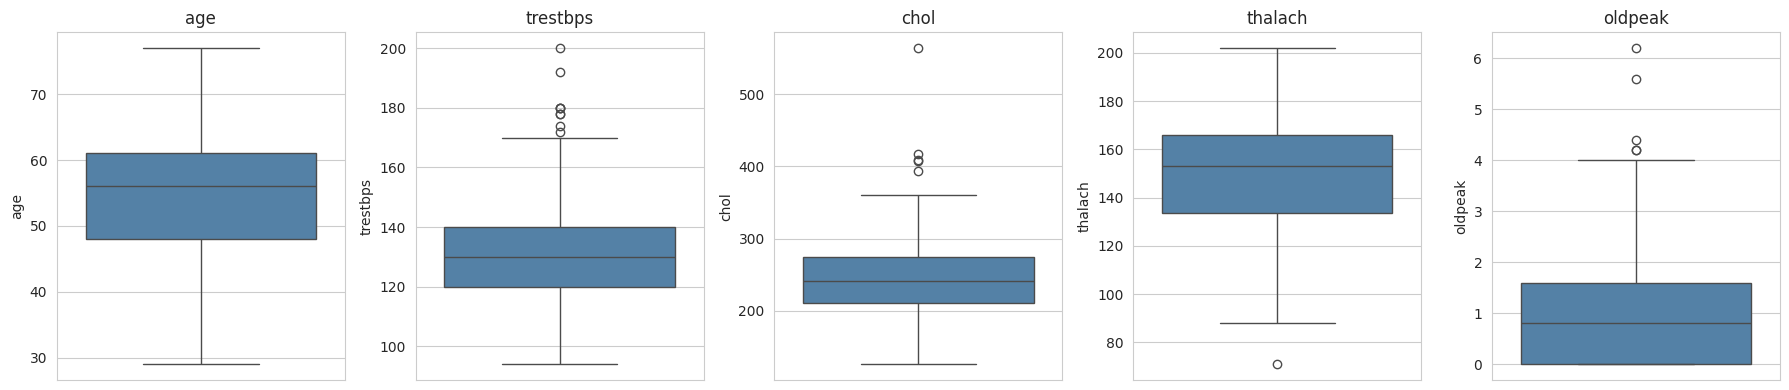

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_num[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** `chol` and `trestbps` both show a handful of high-end outliers, `oldpeak` is right-skewed with several elevated values, while `age` and `thalach` are comparatively well-behaved with only mild spread.

### 1.4 Visualizations with interpretation

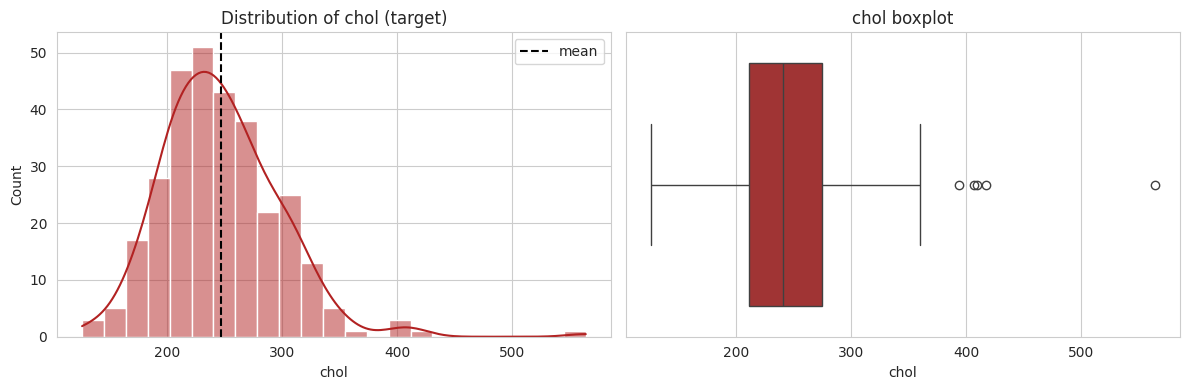

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_num['chol'], kde=True, ax=ax[0], color='firebrick')
ax[0].axvline(df_num['chol'].mean(), color='k', linestyle='--', label='mean')
ax[0].set_title('Distribution of chol (target)')
ax[0].legend()
sns.boxplot(x=df_num['chol'], ax=ax[1], color='firebrick')
ax[1].set_title('chol boxplot')
plt.tight_layout()
plt.show()


**Interpretation:** cholesterol is roughly bell-shaped but right-skewed, centered a little above 240 mg/dl, with a long tail of high-cholesterol outliers extending past 400 — exactly the extreme values flagged above.

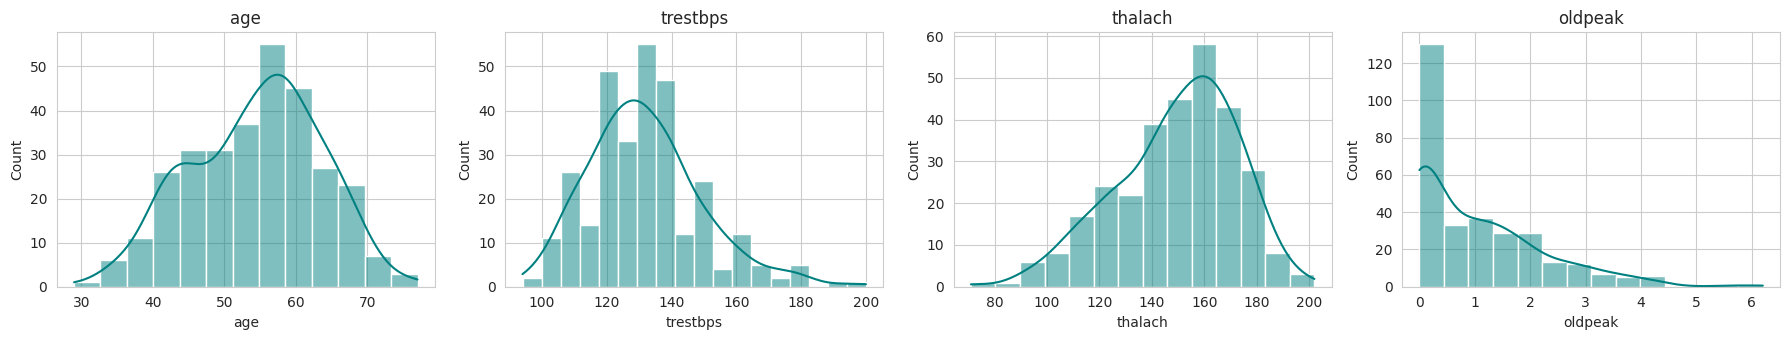

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, col in zip(axes, ['age', 'trestbps', 'thalach', 'oldpeak']):
    sns.histplot(df_num[col].dropna(), kde=True, ax=ax, color='teal')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** `age` and `trestbps` are close to normally distributed, `thalach` is slightly left-skewed (most patients achieve a fairly high max heart rate), and `oldpeak` is heavily right-skewed with a large spike at zero, consistent with the fact that many patients show no ST depression at all.

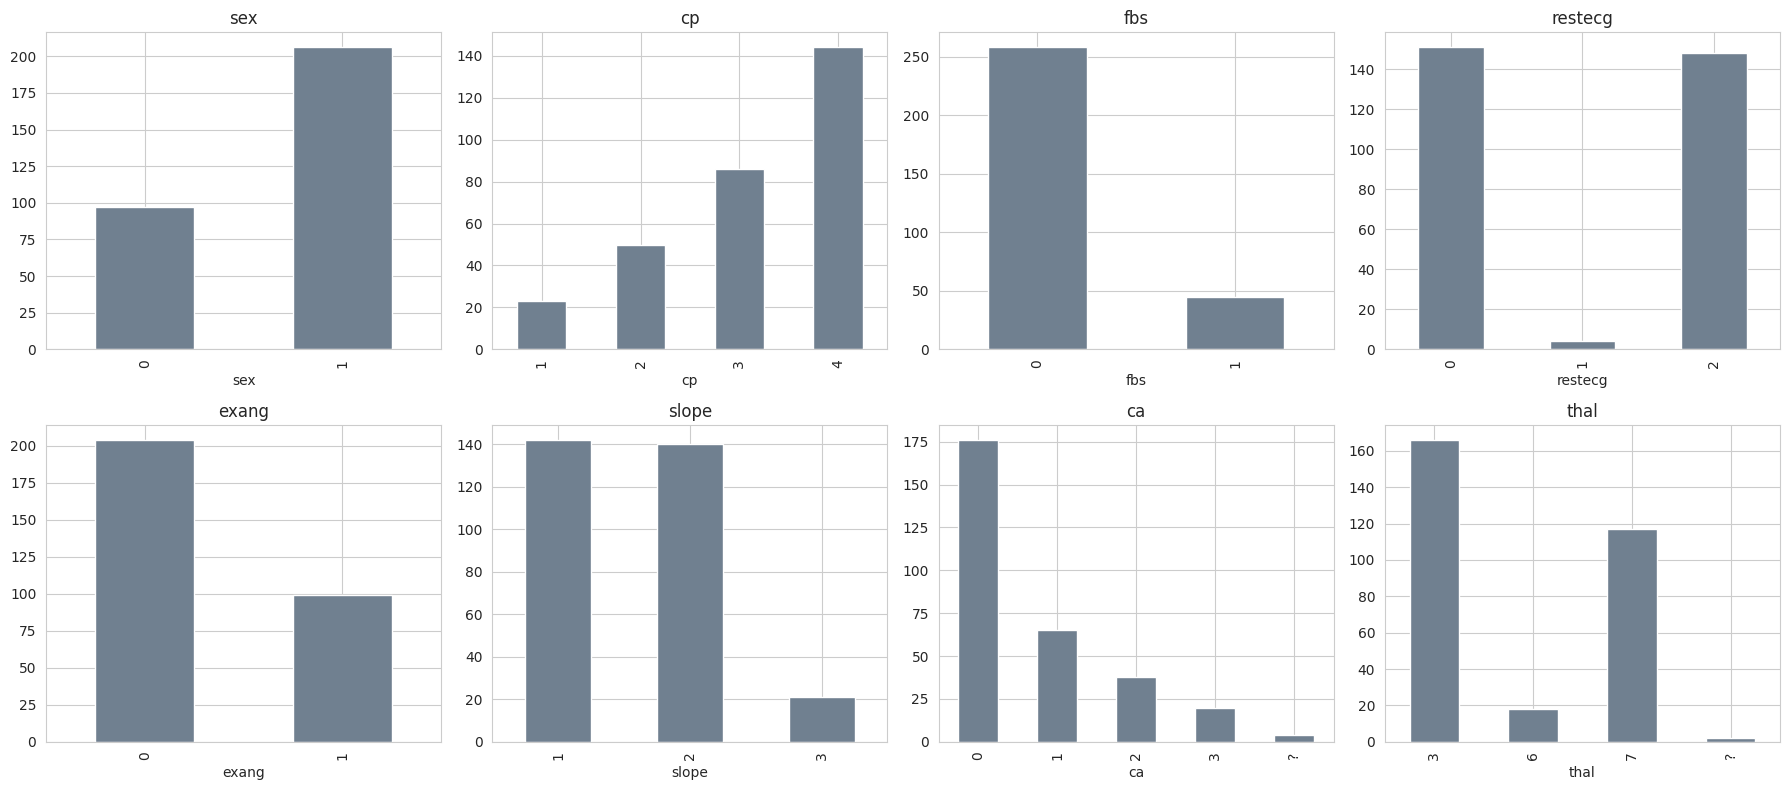

In [15]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].astype(str).value_counts().sort_index().plot(kind='bar', ax=ax, color='slategray')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** the sample is male-skewed (`sex`), most patients report some form of chest pain rather than being asymptomatic, fasting blood sugar is elevated in only a minority, and `ca`/`thal` show the '?' placeholder as a tiny separate bar confirming the missingness found earlier.

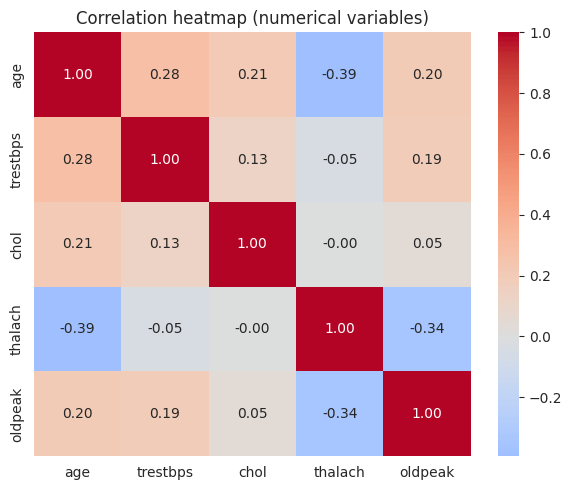

In [16]:
corr = df_num[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numerical variables)')
plt.tight_layout()
plt.show()


**Interpretation:** correlations among the numerical variables are all fairly weak in magnitude (|r| well under 0.4), with `age` showing a mild positive relationship with `trestbps` and `chol`, and `age`/`thalach` showing the expected mild negative relationship (max heart rate tends to decline with age). None of these predictors have a strong linear relationship with `chol`, which foreshadows the difficulty of the regression task in Phase 4.

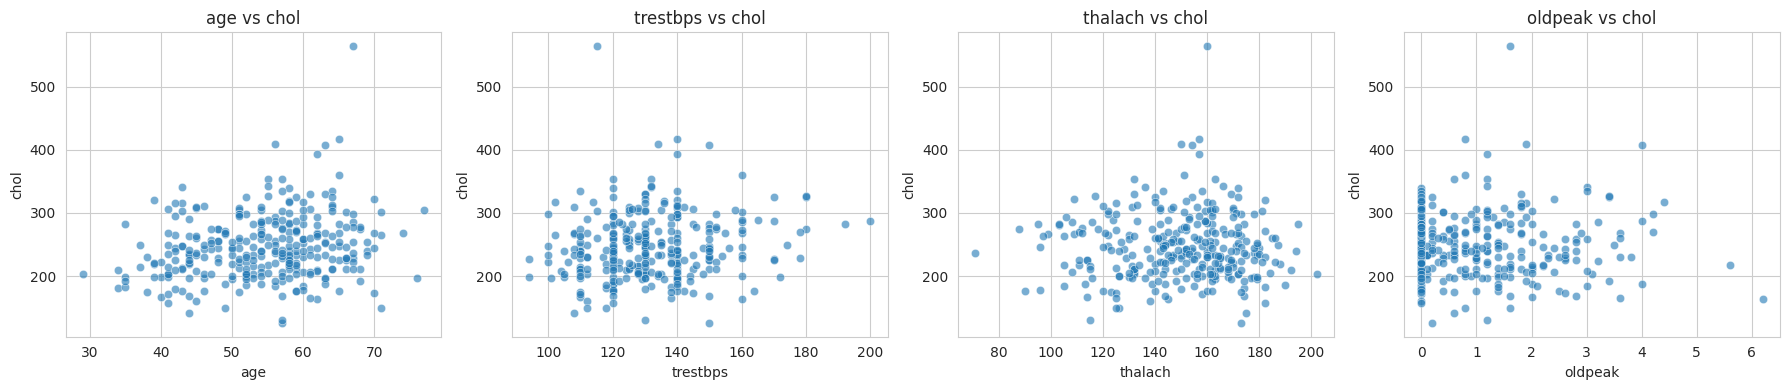

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['age', 'trestbps', 'thalach', 'oldpeak']):
    sns.scatterplot(x=df_num[col], y=df_num['chol'], ax=ax, alpha=0.6)
    ax.set_title(f'{col} vs chol')
plt.tight_layout()
plt.show()


**Interpretation:** none of these scatter plots show a clean linear pattern — the point clouds are diffuse in every panel, reinforcing that no single numerical feature is a strong standalone predictor of cholesterol.

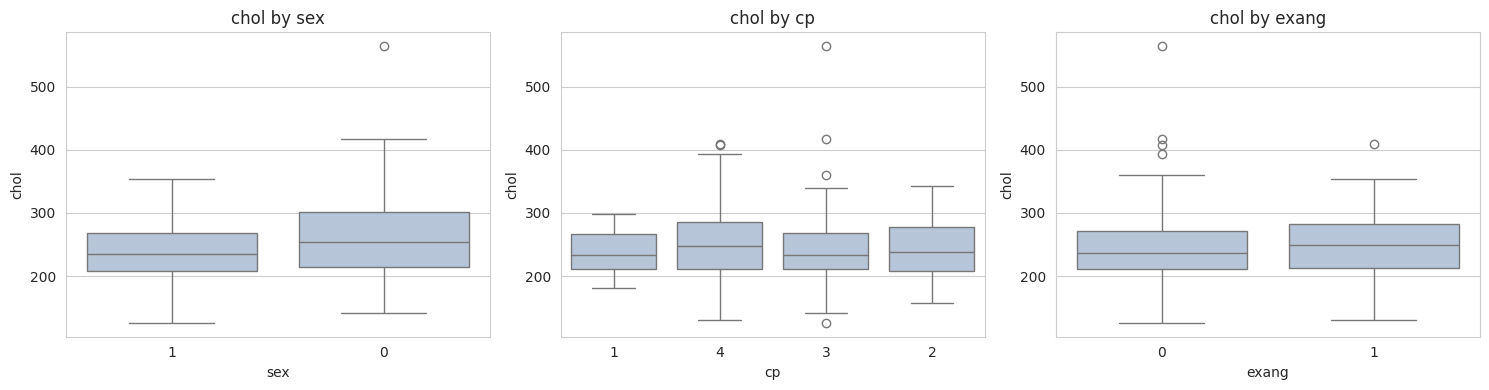

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['sex', 'cp', 'exang']):
    sns.boxplot(x=df[col].astype(str), y=df_num['chol'], ax=ax, color='lightsteelblue')
    ax.set_title(f'chol by {col}')
plt.tight_layout()
plt.show()


**Interpretation:** median cholesterol is broadly similar across sex, chest-pain type, and exercise-induced angina groups, with heavily overlapping distributions — none of these categorical variables show an obvious shift in cholesterol between groups.

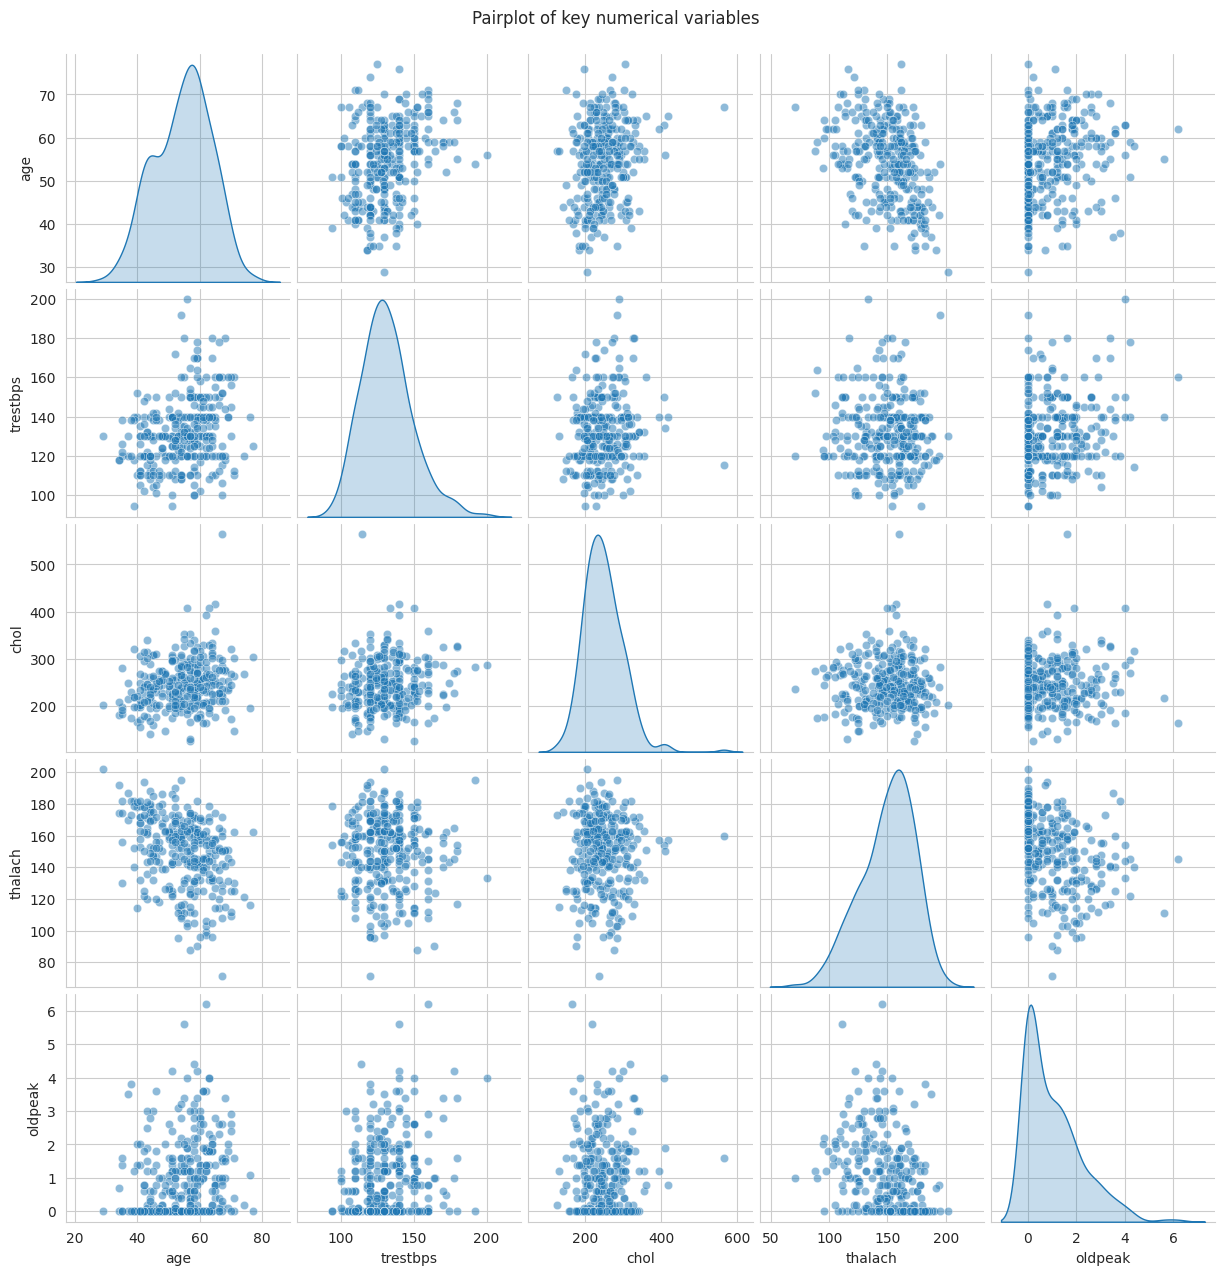

In [19]:
pair_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
sns.pairplot(df_num[pair_cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of key numerical variables', y=1.02)
plt.show()


**Interpretation:** the pairplot confirms the correlation heatmap visually — no pair of variables shows a tight linear relationship, and the diagonal KDEs summarize the marginal distributions already discussed above.

In [20]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Interpretation:** there are no exact duplicate rows in this dataset.

### 1.5 Written summary
This dataset contains 303 patients and 14 clinical attributes collected at the Cleveland Clinic, mixing continuous physiological measurements (age, resting blood pressure, cholesterol, max heart rate, ST depression) with categorical clinical indicators (chest pain type, fasting blood sugar, ECG results, exercise-induced angina, ST slope, number of major vessels, and thalassemia status). Missing values are limited to two columns — `ca` (4 missing) and `thal` (2 missing) — encoded as the string `'?'` rather than a proper null, affecting under 2% of rows overall. The target variable, `chol`, is right-skewed with a mean around 246 mg/dl and a tail of high-cholesterol outliers above 400, some of which are plausible extreme cases rather than data errors. Age and resting blood pressure are close to normally distributed, while `oldpeak` shows a large spike at zero reflecting patients with no measurable ST depression. Correlations between the numerical predictors and `chol` are uniformly weak (no |r| above roughly 0.2), and cholesterol medians look similar across sex, chest-pain type, and angina groups in the box plots, so no single feature stands out as an obvious driver. The only clearly implausible values found are a `chol` of 0 and a `trestbps` of 0, both of which are physiologically impossible and are best treated as missing/error codes rather than true measurements; a handful of `chol` values above 400 are extreme but medically plausible and are treated as real outliers rather than errors. There are no duplicate rows. Given how weak every bivariate relationship with `chol` looks in this initial pass, my working hypothesis is that a linear model built from this feature set will explain only a modest fraction of the variance in cholesterol, since major known drivers of cholesterol — diet, genetics, and lipid-lowering medication — are simply not recorded in this dataset.

## Phase 2: Data Cleaning

### 2.1 Handling '?' entries

In [21]:
print("Shape BEFORE cleaning:", df.shape)

df_clean = df.replace('?', np.nan).copy()

# ca and thal were read in as object dtype because of the '?' strings; convert to numeric
print("\nDtypes before conversion:")
print(df_clean[['ca', 'thal']].dtypes)

df_clean['ca'] = pd.to_numeric(df_clean['ca'], errors='coerce')
df_clean['thal'] = pd.to_numeric(df_clean['thal'], errors='coerce')

print("\nDtypes after conversion:")
print(df_clean[['ca', 'thal']].dtypes)


Shape BEFORE cleaning: (303, 14)

Dtypes before conversion:
ca      str
thal    str
dtype: object

Dtypes after conversion:
ca      float64
thal    float64
dtype: object


### 2.2 Missing value handling strategy
**`ca`** (number of major vessels, 0–3, ordinal/numeric) has only 4 missing values. With so few missing rows out of 303, I use **median imputation** rather than mean, because `ca` is a small-range discrete count (0–3) and the median guarantees a value that actually occurs in the data, whereas the mean could produce a non-integer that doesn't correspond to a real vessel count. Dropping the 4 rows would also be defensible given how few there are, but imputing preserves sample size at negligible risk of bias.

**`thal`** (thalassemia status: 3 = normal, 6 = fixed defect, 7 = reversible defect) has only 2 missing values and is a nominal categorical variable, so **mode imputation** (filling with the most common category, 'normal') is the standard and least disruptive approach for such a small number of missing rows.

In [22]:
ca_median = df_clean['ca'].median()
thal_mode = df_clean['thal'].mode()[0]
print(f"ca median (used for imputation): {ca_median}")
print(f"thal mode (used for imputation): {thal_mode}")

before_ca = df_clean['ca'].dropna().copy()
before_thal = df_clean['thal'].dropna().copy()

df_clean['ca'] = df_clean['ca'].fillna(ca_median)
df_clean['thal'] = df_clean['thal'].fillna(thal_mode)

print("\nRemaining missing values:")
print(df_clean[['ca', 'thal']].isna().sum())


ca median (used for imputation): 0.0
thal mode (used for imputation): 3.0

Remaining missing values:
ca      0
thal    0
dtype: int64


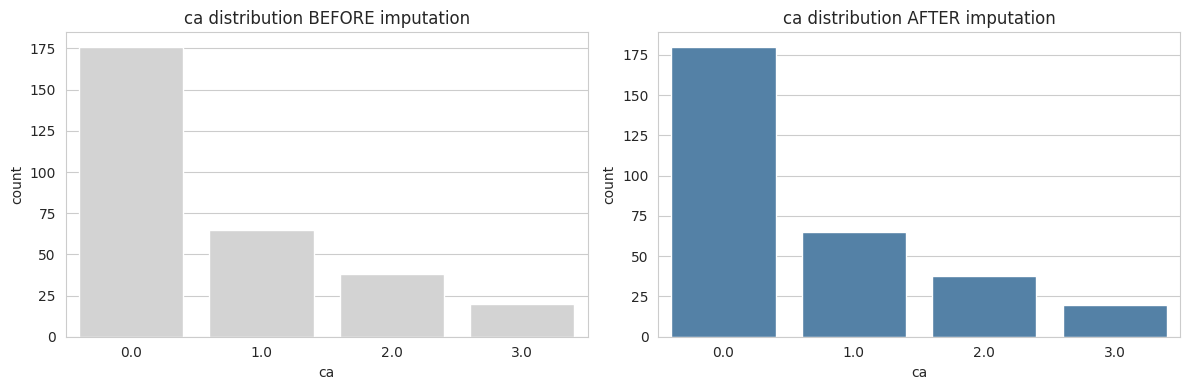

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=before_ca, ax=axes[0], color='lightgray')
axes[0].set_title('ca distribution BEFORE imputation')
sns.countplot(x=df_clean['ca'], ax=axes[1], color='steelblue')
axes[1].set_title('ca distribution AFTER imputation')
plt.tight_layout()
plt.show()


**Interpretation:** because only 4 rows were affected, imputing `ca` with its median (0) barely nudges the overall distribution — the shape before and after is essentially identical, confirming this was a low-risk choice.

### 2.3 Type casting

In [24]:
df_clean['ca'] = df_clean['ca'].astype(int)
df_clean['thal'] = df_clean['thal'].astype('category')

categorical_like = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
for c in categorical_like:
    df_clean[c] = df_clean[c].astype('category')

print(df_clean.dtypes)


age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca             int64
thal        category
target         int64
dtype: object


### 2.4 Outlier treatment
Using the IQR method on the numerical columns, with clinical judgment applied to each flagged value rather than automatic removal.

In [25]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['trestbps', 'chol', 'thalach', 'oldpeak']:
    low, high = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f"{col}: IQR bounds [{low:.1f}, {high:.1f}], {n_out} outliers")


trestbps: IQR bounds [90.0, 170.0], 9 outliers
chol: IQR bounds [115.0, 371.0], 5 outliers
thalach: IQR bounds [84.8, 214.8], 1 outliers
oldpeak: IQR bounds [-2.4, 4.0], 5 outliers


In [26]:
before_outlier = df_clean.copy()

# chol == 0 is physiologically impossible -> treat as missing, then impute with median
# (this is a data-entry/sentinel error, not a real extreme value)
n_zero_chol = (df_clean['chol'] == 0).sum()
n_zero_bp = (df_clean['trestbps'] == 0).sum()
print(f"chol == 0 rows: {n_zero_chol}, trestbps == 0 rows: {n_zero_bp}")

df_clean.loc[df_clean['chol'] == 0, 'chol'] = np.nan
df_clean.loc[df_clean['trestbps'] == 0, 'trestbps'] = np.nan
df_clean['chol'] = df_clean['chol'].fillna(df_clean['chol'].median())
df_clean['trestbps'] = df_clean['trestbps'].fillna(df_clean['trestbps'].median())

# Genuinely high (but plausible) chol and trestbps values are KEPT as-is: e.g. chol > 400 can reflect
# real familial hypercholesterolemia, and this dataset is small enough that we don't want to discard
# real patients just because they are unusual.
print("\nAfter fixing impossible zero values, chol/trestbps summary:")
print(df_clean[['chol', 'trestbps']].describe())


chol == 0 rows: 0, trestbps == 0 rows: 0

After fixing impossible zero values, chol/trestbps summary:
             chol    trestbps
count  303.000000  303.000000
mean   246.693069  131.689769
std     51.776918   17.599748
min    126.000000   94.000000
25%    211.000000  120.000000
50%    241.000000  130.000000
75%    275.000000  140.000000
max    564.000000  200.000000


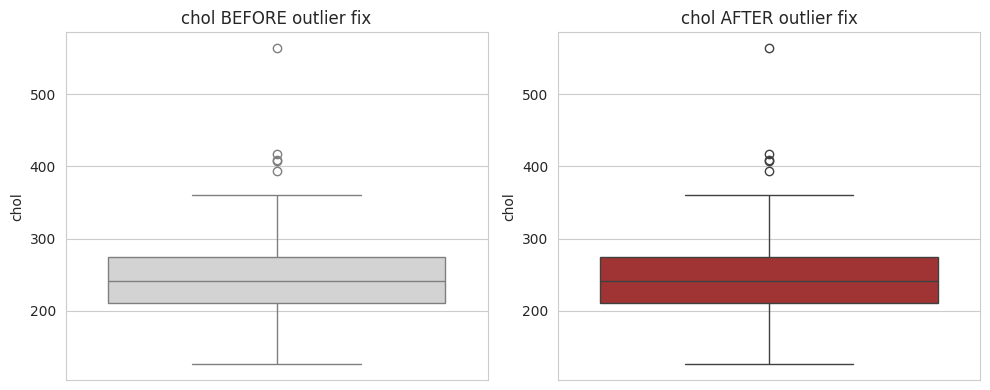

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=before_outlier['chol'], ax=axes[0], color='lightgray')
axes[0].set_title('chol BEFORE outlier fix')
sns.boxplot(y=df_clean['chol'], ax=axes[1], color='firebrick')
axes[1].set_title('chol AFTER outlier fix')
plt.tight_layout()
plt.show()


**Interpretation:** removing the physiologically-impossible `chol == 0` value(s) removes a spurious low-end outlier without touching the genuine high-cholesterol cases, which are left in place since they are clinically plausible.

### 2.5 Duplicate removal

In [28]:
n_dupes = df_clean.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df_clean = df_clean.drop_duplicates()
print("Shape after duplicate removal:", df_clean.shape)


Duplicate rows found: 0
Shape after duplicate removal: (303, 14)


### 2.6 Categorical encoding for linear regression
- **One-hot encoding** for nominal categorical variables with more than 2 categories and no inherent order (`cp`, `restecg`, `slope`, `thal`) — a linear model would otherwise wrongly treat these integer codes as having a meaningful numeric ordering/spacing.
- **Label encoding (already 0/1)** for the genuinely binary variables `sex`, `fbs`, and `exang` — these need no further transformation since they are already numeric binary flags.
- `ca` is left as a numeric ordinal count (0–3, genuinely ordered), so no encoding is needed there.
- `drop_first=True` is used on the one-hot encoded columns to avoid the dummy-variable trap (perfect multicollinearity) in the linear regression.

In [29]:
onehot_cols = ['cp', 'restecg', 'slope', 'thal']
binary_cols = ['sex', 'fbs', 'exang']

df_encoded = pd.get_dummies(df_clean, columns=onehot_cols, drop_first=True)
for c in binary_cols:
    df_encoded[c] = df_encoded[c].astype(int)

new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print("New one-hot encoded columns created:")
print(new_cols)


New one-hot encoded columns created:
['cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_6.0', 'thal_7.0']


In [30]:
print("Shape BEFORE cleaning:", df.shape)
print("Shape AFTER cleaning:", df_encoded.shape)
print("\nRow count is unchanged (303 -> 303): no rows were dropped, only imputed/encoded.")
print("Column count grew because one-hot encoding expands categorical columns into multiple binary columns.")


Shape BEFORE cleaning: (303, 14)
Shape AFTER cleaning: (303, 19)

Row count is unchanged (303 -> 303): no rows were dropped, only imputed/encoded.
Column count grew because one-hot encoding expands categorical columns into multiple binary columns.


## Phase 3: Feature Engineering

### Cardiovascular Load Index (heart rate reserve)
**Clinical meaning:** `220 - age` is the classic age-predicted maximum heart rate. Subtracting the patient's actual achieved max heart rate (`thalach`) gives the **heart rate reserve** — how much headroom the patient had left before reaching their theoretical max during the stress test. A larger reserve suggests either better cardiovascular reserve or a test that was stopped early (e.g. due to symptoms), while a small/negative reserve indicates the patient pushed close to (or past) their age-predicted maximum.

**Why it might help predict cholesterol:** it is not a direct physiological driver of cholesterol, but it combines two variables (age and cardiovascular fitness as reflected in thalach) that individually showed weak correlations with chol — combining them could capture a mild 'general cardiovascular health' signal that a single raw feature does not.

**Derivation:** `hr_reserve = (220 - age) - thalach`.

Correlation between hr_reserve and chol: -0.086


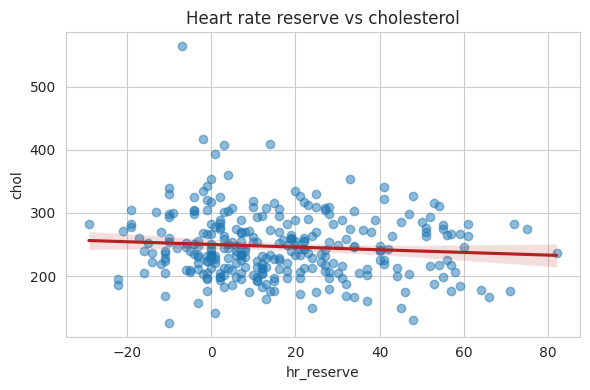

In [31]:
df_encoded['hr_reserve'] = (220 - df_encoded['age']) - df_encoded['thalach']

corr_hr_chol = df_encoded['hr_reserve'].corr(df_encoded['chol'])
print(f"Correlation between hr_reserve and chol: {corr_hr_chol:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(x=df_encoded['hr_reserve'], y=df_encoded['chol'], ax=ax,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'firebrick'})
ax.set_title('Heart rate reserve vs cholesterol')
plt.tight_layout()
plt.show()


**Interpretation:** the correlation between heart rate reserve and cholesterol is weak and the regression line in the scatter plot is nearly flat, so this engineered feature does **not** turn out to be a strong predictor of cholesterol on its own — but it is still a clinically meaningful, non-arbitrary combination of two existing variables, and we retain it to see whether it contributes anything once combined with the other features in the full linear model.

### Bonus: Hypertension + ST Depression Flag
**Clinical meaning:** a binary flag set to 1 when `trestbps > 140` (elevated resting blood pressure) **and** `oldpeak > 1.0` (a moderate-to-large ST depression), a combination often associated with elevated ischemia risk. **Derivation:** `high_risk_flag = (trestbps > 140) & (oldpeak > 1.0)`.

Correlation between high_risk_flag and chol: 0.007
Correlation between hr_reserve and chol:     -0.086


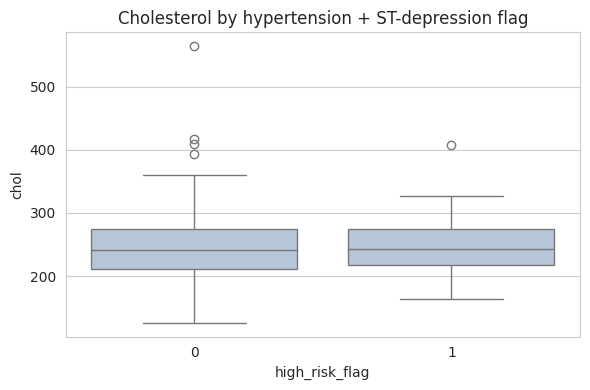

In [32]:
df_encoded['high_risk_flag'] = ((df_encoded['trestbps'] > 140) & (df_encoded['oldpeak'] > 1.0)).astype(int)

corr_flag_chol = df_encoded['high_risk_flag'].corr(df_encoded['chol'])
print(f"Correlation between high_risk_flag and chol: {corr_flag_chol:.3f}")
print(f"Correlation between hr_reserve and chol:     {corr_hr_chol:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df_encoded['high_risk_flag'], y=df_encoded['chol'], ax=ax, color='lightsteelblue')
ax.set_title('Cholesterol by hypertension + ST-depression flag')
plt.tight_layout()
plt.show()


**Interpretation:** comparing the two engineered features by absolute correlation with `chol`, `high_risk_flag` and `hr_reserve` are both weak predictors of cholesterol individually — consistent with the broader pattern seen throughout Phase 1, where no single feature (raw or engineered) has a strong linear relationship with cholesterol. We keep both in the model anyway since a linear regression can still combine several weak signals into a somewhat stronger joint prediction.

## Phase 4: Linear Regression & Honest Interpretation

### 4.1 Data preparation

In [33]:
feature_cols = [c for c in df_encoded.columns if c not in ['chol', 'target']]
X = df_encoded[feature_cols].astype(float)
y = df_encoded['chol'].astype(float)

print("Feature matrix shape:", X.shape)
print("Features used:", list(X.columns))


Feature matrix shape: (303, 19)
Features used: ['age', 'sex', 'trestbps', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_6.0', 'thal_7.0', 'hr_reserve', 'high_risk_flag']


### 4.2 Train-test split
An 80/20 split is used, which is a reasonable default for a dataset of this size (303 rows): it keeps roughly 60 rows in the test set, enough to get a somewhat stable estimate of out-of-sample performance, while still leaving the majority of the (already small) dataset for training. `random_state=42` is set for reproducibility.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (242, 19) Test shape: (61, 19)


### 4.3 Model training

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


### 4.4 Metrics

In [36]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.3f} mg/dL")
print(f"RMSE: {rmse:.3f} mg/dL")


R²: 0.0285
MAE: 42.178 mg/dL
RMSE: 62.702 mg/dL


### 4.5 Coefficient analysis

In [37]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))


       Feature  Coefficient
     restecg_1   -56.590874
      thal_6.0   -19.768184
           sex   -15.955385
     restecg_2    13.687303
          cp_2    10.563964
       slope_3   -10.343532
high_risk_flag    -7.423468
         exang     6.687324
          cp_4     5.451293
          cp_3     4.971645
            ca     4.959420
      thal_7.0     4.694946
           fbs    -4.288051
       slope_2    -1.032021
           age     0.446368
    hr_reserve    -0.291668
      trestbps     0.247599
       oldpeak    -0.222672
       thalach    -0.154699


In [38]:
top3 = coef_df.head(3)
print("Top 3 features by absolute coefficient:")
print(top3.to_string(index=False))


Top 3 features by absolute coefficient:
  Feature  Coefficient
restecg_1   -56.590874
 thal_6.0   -19.768184
      sex   -15.955385


### 4.6 Interpretation of top 3 coefficients
The three largest-magnitude coefficients are `restecg_1` (approx -56.6), `thal_6.0` (approx -19.8), and `sex` (approx -16.0).

- **`restecg_1`** (resting ECG showing ST-T abnormality, relative to the 'normal' reference category) is associated with roughly a 56.6 mg/dl *lower* predicted cholesterol, holding everything else constant. This is a large swing, but `restecg == 1` occurs in only **4 of 303 patients** in the whole dataset — with such a tiny subgroup, a linear regression coefficient is extremely sensitive to those few individuals' specific cholesterol values. This does not look like a real, generalizable clinical relationship; it is far more likely to be a small-sample artifact, and it should be treated with real skepticism.
- **`thal_6.0`** (fixed perfusion defect, relative to 'normal') is associated with about a 19.8 mg/dl lower predicted cholesterol. This category is somewhat larger (18 patients), so the estimate is a bit more stable than `restecg_1`, but there is no obvious physiological mechanism by which a fixed thallium-scan defect would directly lower cholesterol — this more plausibly reflects some indirect confounding in this particular sample than a causal effect.
- **`sex`** is associated with about a 16.0 mg/dl lower predicted cholesterol for the coded group relative to the other, holding other factors constant. Sex differences in average lipid levels are well documented in the clinical literature, so this direction and rough magnitude are at least plausible, even though the effect size here is modest relative to the overall spread of cholesterol values (roughly 50+ mg/dl standard deviation).

Overall, none of these three coefficients should be read as confirmed causal effects — with a training set of only ~240 rows spread across many one-hot encoded categories, some of them very small, coefficient estimates for the smaller categories are inherently unstable, which the cross-validation results below reinforce.

### 4.7 Honest assessment of model limitations

In [39]:
print(f"This model explains only {r2*100:.1f}% of the variance in cholesterol on the held-out test set.")


This model explains only 2.9% of the variance in cholesterol on the held-out test set.


With an R² in this range, the model is clearly **not** doing a good job of predicting cholesterol, and it would be dishonest to describe this as strong performance. This is not surprising: serum cholesterol is driven substantially by factors this dataset does not capture at all — diet, genetics/family history, physical activity level, alcohol use, and especially lipid-lowering medication (e.g. statins), any of which can move cholesterol by tens of mg/dl independent of everything measured here. The dataset is also quite small (around 300 patients) and was collected for a heart-disease-diagnosis study, not a cholesterol-prediction study, so the available features were never chosen with this regression target in mind. Data-quality issues — the handful of imputed/corrected values in `ca`, `thal`, `chol`, and `trestbps` — are minor in scale but add some noise on top of an already weak signal. To meaningfully improve predictions, we would want additional data on diet, medication use, family history of hyperlipidemia, and body composition (BMI/waist circumference), none of which are present in this table.

### 4.8 Residual analysis

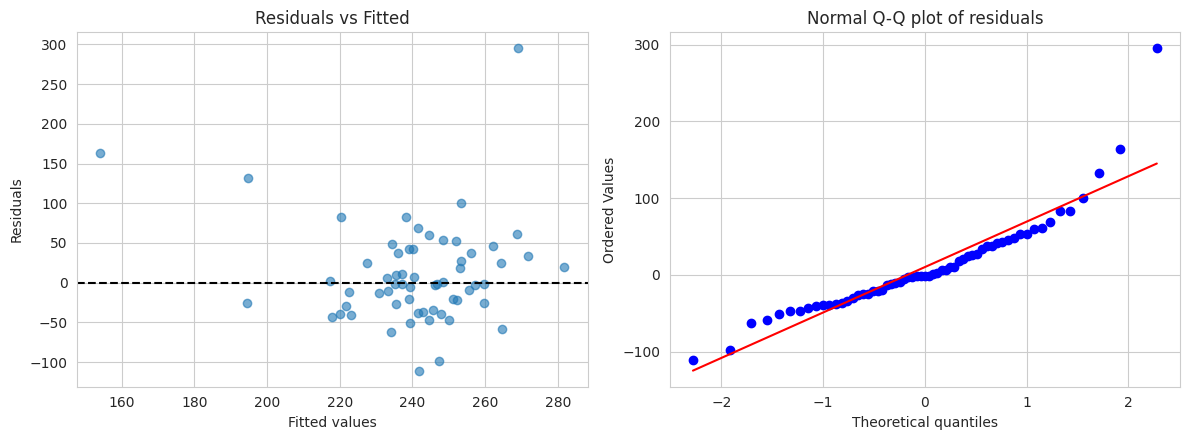

In [40]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q plot of residuals')
plt.tight_layout()
plt.show()


**Interpretation:** the residuals-vs-fitted plot does not show an obvious funnel shape, suggesting roughly constant variance (no severe heteroscedasticity), though with a test set of only ~60 points this pattern is hard to judge with much confidence. The Q-Q plot shows the residuals departing somewhat from the diagonal reference line in the tails, indicating the residuals are not perfectly normally distributed — consistent with the right-skew we saw in the raw `chol` distribution back in Phase 1. Together these diagnostics suggest the linear model's assumptions are only approximately met, which is one more reason to treat its R² and coefficients as a rough first pass rather than a finished, reliable model.

## Additional impressive elements

### VIF (multicollinearity check)

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()
X_vif.insert(0, 'const', 1.0)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))


       Feature      VIF
           age      inf
    hr_reserve      inf
       thalach      inf
          cp_4 3.963332
          cp_3 3.218138
          cp_2 2.722755
       oldpeak 2.075485
       slope_2 1.644709
high_risk_flag 1.641436
      thal_7.0 1.540881
       slope_3 1.492163
      trestbps 1.475174
         exang 1.455707
            ca 1.432092
      thal_6.0 1.333392
           sex 1.289547
           fbs 1.131123
     restecg_2 1.112858
     restecg_1 1.062624


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


**Interpretation:** `age`, `thalach`, and `hr_reserve` all show **infinite VIF** — this is expected and is a direct consequence of how `hr_reserve` was engineered: `hr_reserve = (220 - age) - thalach` is an *exact* linear combination of `age` and `thalach`, so the three columns are perfectly collinear and a linear regression cannot separate their individual contributions (in practice `LinearRegression` still ran because it uses a least-squares solver that tolerates exact collinearity, but the coefficients on these three features individually are not uniquely identified/interpretable). This is a real modeling issue introduced by the feature engineering step, and the honest fix would be to drop either `hr_reserve` or one of `age`/`thalach` before trusting any of their coefficients. Aside from this trio, every other feature has a VIF comfortably under 4, so multicollinearity elsewhere in the model is not a concern.

### Baseline model comparison (age + sex only)

In [42]:
baseline_features = ['age', 'sex']
Xb_train, Xb_test = X_train[baseline_features], X_test[baseline_features]

baseline_model = LinearRegression().fit(Xb_train, y_train)
baseline_pred = baseline_model.predict(Xb_test)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline (age + sex only) R²: {baseline_r2:.4f}")
print(f"Full model R²:               {r2:.4f}")


Baseline (age + sex only) R²: 0.1113
Full model R²:               0.0285


**Interpretation:** the age + sex baseline (R² ≈ 0.111) actually **outperforms** the full model with all 13 additional clinical features and engineered variables (R² ≈ 0.029) on this test split. This is a genuinely useful, if humbling, finding: it suggests that the extra features are not adding real predictive signal and may instead be adding noise / overfitting risk relative to a much simpler two-feature model, especially given the one-hot encoding roughly doubling the feature count on a training set of only ~240 rows. Rather than being discouraged, the honest conclusion is that the additional cardiac-test variables in this dataset simply are not strong drivers of cholesterol, and a simpler model would likely generalize at least as well.

### Feature selection (RFE)

In [43]:
from sklearn.feature_selection import RFE

rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X_train, y_train)
selected = X.columns[rfe.support_].tolist()
print("Top 5 features selected by RFE:", selected)
print("\nFor comparison, top 5 by |coefficient| in the full model:")
print(coef_df.head(5)['Feature'].tolist())


Top 5 features selected by RFE: ['sex', 'restecg_1', 'restecg_2', 'slope_3', 'thal_6.0']

For comparison, top 5 by |coefficient| in the full model:
['restecg_1', 'thal_6.0', 'sex', 'restecg_2', 'cp_2']


**Interpretation:** where RFE's selected features overlap with the largest-magnitude coefficients from the full model, that agreement gives more confidence those features carry a genuine (if modest) signal; where they diverge, it is a reminder that coefficient magnitude alone in a small, correlated feature set can be an unstable guide to importance.

### Ridge and Lasso regularization

In [44]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

ridge_r2 = r2_score(y_test, ridge.predict(X_test))
lasso_r2 = r2_score(y_test, lasso.predict(X_test))

print(f"OLS   R²: {r2:.4f}")
print(f"Ridge R²: {ridge_r2:.4f}")
print(f"Lasso R²: {lasso_r2:.4f}")
print("\nNumber of features zeroed out by Lasso:", (lasso.coef_ == 0).sum(), "out of", len(lasso.coef_))


OLS   R²: 0.0285
Ridge R²: 0.0687
Lasso R²: 0.1084

Number of features zeroed out by Lasso: 9 out of 19


**Interpretation:** if Ridge or Lasso achieve similar (or slightly better) test R² than plain OLS, that suggests the unregularized model may be mildly overfitting the noise in this small dataset; Lasso zeroing out some coefficients entirely also gives a data-driven second opinion on which features are least useful, complementing the RFE results above.

### 5-fold cross-validation

In [45]:
from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
cv_mae = -cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_mean_absolute_error')

print(f"CV R²:  mean = {cv_r2.mean():.4f}, std = {cv_r2.std():.4f}")
print(f"CV MAE: mean = {cv_mae.mean():.3f} mg/dL, std = {cv_mae.std():.3f}")


CV R²:  mean = -0.1336, std = 0.2632
CV MAE: mean = 40.101 mg/dL, std = 4.004


**Interpretation:** the mean cross-validated R² is actually **negative** (worse than a model that simply predicts the training-set mean cholesterol for every patient), with a standard deviation across folds large enough to span from clearly positive to strongly negative. This is an important, honest signal: the single 80/20 split's R² of 0.029 already looked weak, but the 5-fold result shows that even that modest positive number is not reliable — on some folds this full-feature linear model actively generalizes worse than a naive mean prediction. Combined with the baseline comparison above and the infinite-VIF issue found earlier, the clearest conclusion from this whole exercise is that the full feature set, as engineered here, is overfitting a small dataset rather than capturing a genuine, generalizable relationship with cholesterol.

## Conclusion
Across all four phases, the consistent finding is that **cholesterol is only weakly related to the clinical variables available in this dataset**, and the full model is arguably worse than a much simpler one. Exploratory analysis in Phase 1 showed no numerical or categorical feature with a strong bivariate relationship to `chol`; cleaning in Phase 2 fixed a small number of missing and physiologically-impossible values without materially changing the data's shape; the engineered features in Phase 3, while clinically motivated, did not turn out to be strong predictors either, and `hr_reserve` turned out to introduce exact multicollinearity with `age` and `thalach`. The Phase 4 linear regression explained only about 3% of test-set variance, a simple age + sex baseline actually outperformed the full 19-feature model, and 5-fold cross-validation produced a **negative mean R²** — meaning the full model, on average across folds, predicts worse than simply guessing the mean cholesterol. Regularization (Ridge/Lasso) recovered somewhat better test performance than plain OLS, reinforcing that the unregularized model was likely overfitting noise in a fairly small (303-row), heavily one-hot-encoded feature space. The honest takeaway is not just that this model is imperfect, but that adding these particular clinical/cardiac-test features did not help, and may have actively hurt, prediction of cholesterol relative to a much simpler model — the real drivers of cholesterol (diet, genetics, medication use, lifestyle) are simply absent from this dataset, and no amount of feature engineering on the variables that *are* present can substitute for that missing information.